# Workflow Test: Vacuum Gripper
### Geometries, Gripper, Grasp Sampler

In [1]:
import os
from os.path import join as pjoin
import sys
import numpy as np
import open3d as o3d
import yaml
from copy import deepcopy

# Import our custom modules
# from src.grippers.vacuum_gripper import VacuumGripper, VacuumGripperConfig
from src.grippers.vacuum_gripper_v2 import VacuumGripper, VacuumGripperConfig
# from src.grasping.vacuum_sampler import VacuumGraspSampler, VacuumSamplerConfig
from src.grasping.vacuum_sampler_v2 import VacuumGraspSampler, VacuumSamplerConfig
import src.utils.geometry_utils as gu
from src.generic_geometry import GenericGeometry


### Load Configs and data

In [33]:
# franka_path = pjoin("gripper_parameter", "double_quad_cup.yaml")
# franka_path = pjoin("gripper_parameter", "double_quad_cup_2.yaml")
franka_path = pjoin("gripper_parameter", "double_cup.yaml")
# franka_path = pjoin("gripper_parameter", "single_circle_cup.yaml")
# franka_path = pjoin("gripper_parameter", "franka_vacuum.yaml")

# object_path = pjoin("Test_part", "pringles", "clouds","merged_cloud.ply")
# object_path = pjoin("Test_part","Verification_examples","combined.ply")
object_path = r"Test_part/cracker_box/clouds/merged_cloud.ply"
gripper = VacuumGripper(franka_path)
pcd = GenericGeometry(object_path)
# pcd.estimate_normals()

✅ Geometry set: mesh (open3d)
Applying rigid transformation...
🔧 Vacuum Gripper 'Double_Schmalz_ECG' initialized.
   - Active Pads: 2
[Open3D WARNING] geometry::TriangleMesh appears to be a geometry::PointCloud (only contains vertices, but no triangles).
[Open3D] Loaded PointCloud: Test_part/cracker_box/clouds/merged_cloud.ply
✅ Geometry set: point_cloud (open3d)


In [34]:
gripper.visualize()

In [35]:
pcd.visualize()

## Create Grasp Sampler

In [36]:
# 2. Initialize Sampler Configuration
config_path = pjoin("config", "config.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# sampler_config = VacuumSamplerConfig(
#     num_samples=1200,        # Cast 300 rays
#     approach_distance=0.15, # 15cm approach check
#     local_clearence_margin=0.02,
#     safety_volume_shape= "bounding_box_shape",
#     max_angle_deg=45,
#     min_score=0.1,           # Minimum GSS to accept
#     # rotation_strategy='uniform', # 'uniform' or 'fixed'
#     rotation_strategy='uniform', # 'uniform' or 'fixed'
#     rotation_step_deg=10,
#     rotation_range_deg=180,
#     score_aggregation_method="median",
#     debug_score=True

# )

sampler_config = VacuumSamplerConfig(**config)
# 3. Initialize Sampler
sampler = VacuumGraspSampler(gripper, sampler_config)

[VacuumSampler] Using Contact Strategy: projection


### Downsample and Clean

In [37]:
dim_report = pcd.get_dimensions_report()
print("Object dimensions report:")
for k,v in dim_report.items():
    print(f"  {k}: {v}")

Object dimensions report:
  extents_xyz: [0.0978 0.1732 0.236 ]
  diagonal: 0.3086
  likely_unit: meters
  suggested_voxel_size: 0.00309
  details: Type: Open3D PointCloud. Size: 0.10 x 0.17 x 0.24. Unit: METERS.


In [26]:
# GenericGeometry(geometry=gripper.generate_safety_collision_mesh(
#     np.array([0,0,0]),
#     np.array([0,0,1]),
#     0.2
# )).visualize()

In [38]:
voxel_size = 0.001
pcd_down = pcd.downsample(voxel_size=voxel_size)
pcd_down = GenericGeometry(geometry=pcd_down)
pcd_down.visualize()

Downsampling with voxel_size=0.001...
✅ Geometry set: point_cloud (open3d)


In [52]:
# pcd_down.clean_point_cloud(inplace=True)
pcd_down.remove_outliers_physical(inplace=True, min_neighbors=5)
pcd_down.visualize()

✅ Geometry set: point_cloud (open3d)


In [28]:
x = pcd_down.geometry.compute_nearest_neighbor_distance()
np.mean(np.asarray(x))

np.float64(0.0007786248092766149)

### Sample Grasps

In [39]:
# Run the sampling pipeline
# pcd_down = pcd.downsample(voxel_size=0.003)
grasps = sampler.sample_grasps(pcd_down.geometry)

print(f"\nResult: Found {len(grasps)} valid grasps.")

if len(grasps) > 0:
    best_grasp = grasps[0]
    print(f"Top Grasp Score: {best_grasp.score:.4f}")
    print(f"Top Grasp Position: {best_grasp.contact_point}")
else:
    print("No valid grasps found. Check thresholds.")

[Debug] Visualizing Raycasting Mesh (Type: alpha)...
[Debug] Abrindo Visualizador de Raycasting (alpha)...
[VacuumSampler] Phase 1: Generated 2450 candidates.
[Debug Sealing] Expected: 32.9 | Valid: 110 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 67 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 0 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 0 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 0 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 61 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 142 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 133 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 110 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 93 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 71 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 93 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 122 | Spacing: 0.0008
[Debug Sealing] Expected: 32.9 | Valid: 136 | 

In [43]:
# for c in sampler.get_best_candidates(8):
for c in [best_grasp]:
# for c in [sampler.candidates[50]]:
    sampler.visualize_grasp(pcd_down.geometry, c)

✅ Geometry set: mesh (open3d)
Applying rigid transformation...


In [42]:
best_grasp.score_details

{'seal_score': np.float64(1.0),
 'verticality': np.float64(0.9195277151608044),
 'torque': np.float64(0.9421750059975387),
 'raw_angle_deg': np.float64(3.6212528177638004),
 'pad_scores': {'left_cup': np.float64(1.0), 'right_cup': np.float64(1.0)},
 'failure_reason': []}

<Axes: ylabel='Count'>

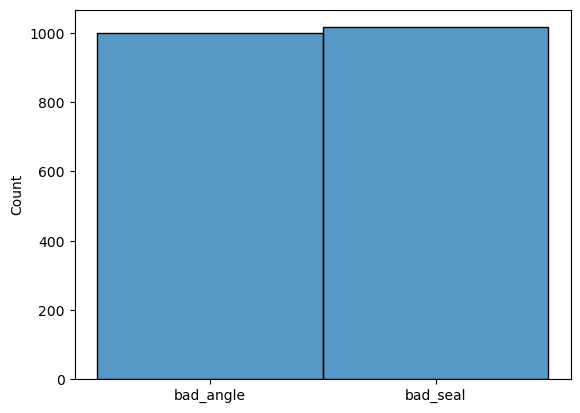

In [10]:
import seaborn as sns
reasons = [c.score_details.get("failure_reason", []) for c in sampler.candidates]
reasons = sum(reasons, start=[])
sns.histplot(reasons)

In [14]:

# # for c in sampler.get_best_candidates(8):
for c in sampler.valid_candidates[:20]:
# for c in [*sampler.candidates[:50]]:
    sampler.visualize_grasp(pcd_down.geometry, c)

✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transforma

In [32]:
sampler.candidates[50].score_details

{'seal_score': np.float64(0.11899155883499378),
 'verticality': np.float64(0.9456026847904638),
 'torque': np.float64(0.7288142888420752),
 'raw_angle_deg': np.float64(2.4478791844291274),
 'pad_scores': {'left_cup': np.float64(0.11899155883499378),
  'right_cup': np.float64(0.5949577941749689)},
 'failure_reason': ['bad_seal']}

(array([482.,   0.,  29.,   0.,   0.,  59.,   0., 119.,   0.,   0., 123.,
          0.,  52.,   0.,   0.,  22.,   0.,  24.,   0., 222.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

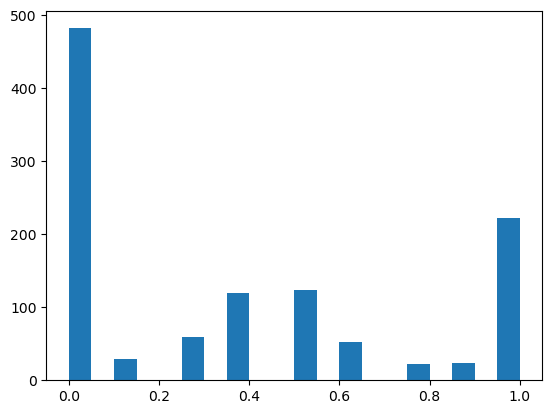

In [14]:
import matplotlib.pyplot as plt
plt.hist(list(map(lambda c: c.score_details.get("seal_score") , sampler.candidates)), bins=20)

In [19]:
sampler.visualize_candidates_heatmap(pcd_down.geometry, valid_only=False, relative_scale=False)

In [20]:
sampler.visualize_candidates_heatmap(pcd_down.geometry,
                                     attribute='verticality',
                                     valid_only=False,
                                     relative_scale=False)

In [13]:
sampler.visualize_candidates_heatmap(pcd_down.geometry,attribute='torque', valid_only=False, )

In [14]:
sampler.visualize_candidates_heatmap(pcd_down.geometry,attribute='seal_score', valid_only=False)